.py version is [extract_color_code.py](extract_color_code.py) of this Jupyter Notebook

In [5]:
# !pip install pandas requests pillow scikit-image numpy

## Setup

### Data Structure and Analysis

In [17]:
import matplotlib.pyplot as plt
import ast
import seaborn as sns
import numpy as np
import pandas as pd

### Web and Images

In [ ]:
import requests
from PIL import Image
from io import BytesIO
from skimage.color import rgb2lab
import time

## Extracting to RGB and Lab

In [7]:
def extract_color_from_url(url):
    """
    Downloads an image from a URL and extracts its dominant RGB 
    and converts it to CIE L*a*b* color space.
    """
    if pd.isna(url) or not isinstance(url, str):
        return None, None, None, None, None, None

    try:
        # 1. Download the image
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        
        # 2. Open image and ensure it's in RGB mode
        img = Image.open(BytesIO(response.content)).convert('RGB')
        
        # 3. Focus on the center to avoid edge artifacts or background transparency
        width, height = img.size
        left = int(width * 0.4)
        top = int(height * 0.4)
        right = int(width * 0.6)
        bottom = int(height * 0.6)
        
        center_crop = img.crop((left, top, right, bottom))
        img_np = np.array(center_crop)
        
        # 4. Calculate the median RGB value of the center area
        # Median is safer than mean to exclude any stray pixel anomalies
        median_r = int(np.median(img_np[:, :, 0]))
        median_g = int(np.median(img_np[:, :, 1]))
        median_b = int(np.median(img_np[:, :, 2]))
        
        # 5. Convert RGB to L*a*b* # skimage expects RGB values normalized between 0 and 1
        rgb_normalized = np.array([[[median_r / 255.0, median_g / 255.0, median_b / 255.0]]])
        lab_normalized = rgb2lab(rgb_normalized)
        
        lab_l = round(float(lab_normalized[0][0][0]), 2)
        lab_a = round(float(lab_normalized[0][0][1]), 2)
        lab_b = round(float(lab_normalized[0][0][2]), 2)
        
        return median_r, median_g, median_b, lab_l, lab_a, lab_b

    except Exception as e:
        # Logs errors (e.g., 404, connection timeout, corrupted images) gracefully
        print(f"Error processing URL {url}: {e}")
        return None, None, None, None, None, None

In [8]:
def process_blush_dataset(input_csv_path, output_csv_path):
    # Load your dataset
    df = pd.read_csv(input_csv_path)
    
    print(f"Loaded {len(df)} rows. Starting color extraction pipeline...")
    
    # Initialize lists to hold our new data
    r_list, g_list, b_list = [], [], []
    lab_l_list, lab_a_list, lab_b_list = [], [], []
    
    for idx, url in enumerate(df['swatch_img_url']):
        # Optional tracking printout every 100 images
        if idx % 100 == 0 and idx > 0:
            print(f"Processed {idx}/{len(df)} images...")
            
        r, g, b, l, a, lab_b_val = extract_color_from_url(url)
        
        r_list.append(r)
        g_list.append(g)
        b_list.append(b)
        lab_l_list.append(l)
        lab_a_list.append(a)
        lab_b_list.append(lab_b_val)
        
        # Polite scraping delay to be kind to Ulta's servers
        time.sleep(0.05) 
        
    # Append the extracted color arrays back to the dataframe
    df['rgb_r'] = r_list
    df['rgb_g'] = g_list
    df['rgb_b'] = b_list
    df['lab_L'] = lab_l_list
    df['lab_a'] = lab_a_list
    df['lab_b'] = lab_b_list
    
    # Save to a new csv
    df.to_csv(output_csv_path, index=False)
    print(f"Pipeline complete! Saved results to {output_csv_path}")

In [9]:
# --- Execution ---
# Replace with your actual file names
process_blush_dataset(r'../clean_data/ulta_clean_blush_v1.csv', r'../clean_data/ulta_clean_blush_with_colors.csv')

Loaded 1514 rows. Starting color extraction pipeline...
Processed 100/1514 images...
Processed 200/1514 images...
Processed 300/1514 images...
Processed 400/1514 images...
Processed 500/1514 images...
Processed 600/1514 images...
Processed 700/1514 images...
Processed 800/1514 images...
Processed 900/1514 images...
Processed 1000/1514 images...
Processed 1100/1514 images...
Processed 1200/1514 images...
Processed 1300/1514 images...
Processed 1400/1514 images...
Processed 1500/1514 images...
Pipeline complete! Saved results to ../clean_data/ulta_clean_blush_with_colors.csv


## Data Analysis

In [ ]:
df = pd.read_csv(r"../clean_data/ulta_clean_blush_with_colors.csv")

In [3]:
# create new rgb column
df['rgb'] = (
    df['rgb_r'].astype(str) + ',' +
    df['rgb_g'].astype(str) + ',' +
    df['rgb_b'].astype(str)
)

In [17]:
df['rgb'].head()

0    255,126,180
1      193,52,58
2      105,25,50
3    222,132,124
4    242,133,156
Name: rgb, dtype: str

In [4]:
# create new Lab column
df['lab'] = (
    df['lab_L'].astype(str) + ',' +
    df['lab_a'].astype(str) + ',' +
    df['lab_b'].astype(str)
)

In [23]:
df['lab'].head()

0     69.1,54.69,-5.27
1    44.38,55.71,30.35
2     23.44,37.06,4.89
3    64.56,33.66,19.24
4     68.06,43.98,6.51
Name: lab, dtype: str

In [28]:
df[df['rgb'].duplicated(keep=False)]

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,standard_value,standard_unit,...,shade_id,product_image_url,rgb_r,rgb_g,rgb_b,lab_L,lab_a,lab_b,rgb,lab
240,https://www.ulta.com/p/intense-matte-lip-cheek...,NUDESTIX,Intense Matte Lip + Cheek Pencil,Pixi,https://media.ultainc.com/i/ulta/2508158_sw?im...,Pixi Intense Matte Lip + Cheek Pencil,neutral nude pink,29.0,2.83,g,...,2508158,https://media.ulta.com/i/ulta/2508158?w=1080&h...,182,108,109,53.79,29.55,12.16,"182,108,109","53.79,29.55,12.16"
315,https://www.ulta.com/p/strawberry-rococo-serie...,Flower Knows,Strawberry Rococo Series Embossed Blush,03 Classic Ballet,https://media.ultainc.com/i/ulta/2650117_sw?im...,03 Classic Ballet Strawberry Rococo Series Emb...,petal pink,26.0,5.10,g,...,2650117,https://media.ulta.com/i/ulta/2650117?w=1080&h...,216,143,150,66.86,28.59,7.74,"216,143,150","66.86,28.59,7.74"
724,https://www.ulta.com/p/powder-blush-mkt7700042...,Sigma Beauty,Powder Blush,Sunset Kiss,https://media.ultainc.com/i/ulta/77000847_sw?i...,Sunset Kiss Powder Blush not available,pink,17.5,7.94,g,...,77000847,https://media.ulta.com/i/ulta/77000847?w=1080&...,226,152,141,69.86,26.42,17.14,"226,152,141","69.86,26.42,17.14"
725,https://www.ulta.com/p/powder-blush-mkt7700042...,Sigma Beauty,Powder Blush,Tiger Lily,https://media.ultainc.com/i/ulta/77000819_sw?i...,Tiger Lily Powder Blush,gold,17.5,7.94,g,...,77000819,https://media.ulta.com/i/ulta/77000819?w=1080&...,239,144,116,69.16,33.11,30.20,"239,144,116","69.16,33.11,30.2"
899,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Cor-de-Rosa,https://media.ultainc.com/i/ulta/77002146_sw?i...,Cor-de-Rosa Cream Blush,pink,34.0,7.09,g,...,77002146,https://media.ulta.com/i/ulta/77002146?w=1080&...,172,91,87,48.19,32.52,17.24,"172,91,87","48.19,32.52,17.24"
900,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Coral Dawn,https://media.ultainc.com/i/ulta/77002145_sw?i...,Coral Dawn Cream Blush,coral,34.0,7.09,g,...,77002145,https://media.ulta.com/i/ulta/77002145?w=1080&...,223,123,99,62.30,36.46,30.26,"223,123,99","62.3,36.46,30.26"
901,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Pashmina,https://media.ultainc.com/i/ulta/77002147_sw?i...,Pashmina Cream Blush,beige,34.0,7.09,g,...,77002147,https://media.ulta.com/i/ulta/77002147?w=1080&...,194,91,84,51.38,40.65,23.83,"194,91,84","51.38,40.65,23.83"
999,https://www.ulta.com/p/powder-blush-duo-mkt770...,Sigma Beauty,Powder Blush Duo,Tiger Lily,https://media.ultainc.com/i/ulta/77007525_sw?i...,Tiger Lily Powder Blush Duo,Bronze,50.0,67.19,g,...,77007525,https://media.ulta.com/i/ulta/77007525?w=1080&...,239,144,116,69.16,33.11,30.20,"239,144,116","69.16,33.11,30.2"
1000,https://www.ulta.com/p/powder-blush-duo-mkt770...,Sigma Beauty,Powder Blush Duo,Sunset Kiss,https://media.ultainc.com/i/ulta/77007530_sw?i...,Sunset Kiss Powder Blush Duo,Gold,50.0,67.19,g,...,77007530,https://media.ulta.com/i/ulta/77007530?w=1080&...,226,152,141,69.86,26.42,17.14,"226,152,141","69.86,26.42,17.14"
1023,https://www.ulta.com/p/gel-color-lip-cheek-bal...,NUDESTIX,Gel Color Lip + Cheek Balm,Pulse,https://media.ultainc.com/i/ulta/2508141_sw?im...,Pulse Gel Color Lip + Cheek Balm,warm rosy pink,29.0,2.83,g,...,2508141,https://media.ulta.com/i/ulta/2508141?w=1080&h...,182,108,109,53.79,29.55,12.16,"182,108,109","53.79,29.55,12.16"


In [29]:
df[df['lab'].duplicated(keep=False)]

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,standard_value,standard_unit,...,shade_id,product_image_url,rgb_r,rgb_g,rgb_b,lab_L,lab_a,lab_b,rgb,lab
240,https://www.ulta.com/p/intense-matte-lip-cheek...,NUDESTIX,Intense Matte Lip + Cheek Pencil,Pixi,https://media.ultainc.com/i/ulta/2508158_sw?im...,Pixi Intense Matte Lip + Cheek Pencil,neutral nude pink,29.0,2.83,g,...,2508158,https://media.ulta.com/i/ulta/2508158?w=1080&h...,182,108,109,53.79,29.55,12.16,"182,108,109","53.79,29.55,12.16"
315,https://www.ulta.com/p/strawberry-rococo-serie...,Flower Knows,Strawberry Rococo Series Embossed Blush,03 Classic Ballet,https://media.ultainc.com/i/ulta/2650117_sw?im...,03 Classic Ballet Strawberry Rococo Series Emb...,petal pink,26.0,5.10,g,...,2650117,https://media.ulta.com/i/ulta/2650117?w=1080&h...,216,143,150,66.86,28.59,7.74,"216,143,150","66.86,28.59,7.74"
724,https://www.ulta.com/p/powder-blush-mkt7700042...,Sigma Beauty,Powder Blush,Sunset Kiss,https://media.ultainc.com/i/ulta/77000847_sw?i...,Sunset Kiss Powder Blush not available,pink,17.5,7.94,g,...,77000847,https://media.ulta.com/i/ulta/77000847?w=1080&...,226,152,141,69.86,26.42,17.14,"226,152,141","69.86,26.42,17.14"
725,https://www.ulta.com/p/powder-blush-mkt7700042...,Sigma Beauty,Powder Blush,Tiger Lily,https://media.ultainc.com/i/ulta/77000819_sw?i...,Tiger Lily Powder Blush,gold,17.5,7.94,g,...,77000819,https://media.ulta.com/i/ulta/77000819?w=1080&...,239,144,116,69.16,33.11,30.20,"239,144,116","69.16,33.11,30.2"
899,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Cor-de-Rosa,https://media.ultainc.com/i/ulta/77002146_sw?i...,Cor-de-Rosa Cream Blush,pink,34.0,7.09,g,...,77002146,https://media.ulta.com/i/ulta/77002146?w=1080&...,172,91,87,48.19,32.52,17.24,"172,91,87","48.19,32.52,17.24"
900,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Coral Dawn,https://media.ultainc.com/i/ulta/77002145_sw?i...,Coral Dawn Cream Blush,coral,34.0,7.09,g,...,77002145,https://media.ulta.com/i/ulta/77002145?w=1080&...,223,123,99,62.30,36.46,30.26,"223,123,99","62.3,36.46,30.26"
901,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Pashmina,https://media.ultainc.com/i/ulta/77002147_sw?i...,Pashmina Cream Blush,beige,34.0,7.09,g,...,77002147,https://media.ulta.com/i/ulta/77002147?w=1080&...,194,91,84,51.38,40.65,23.83,"194,91,84","51.38,40.65,23.83"
999,https://www.ulta.com/p/powder-blush-duo-mkt770...,Sigma Beauty,Powder Blush Duo,Tiger Lily,https://media.ultainc.com/i/ulta/77007525_sw?i...,Tiger Lily Powder Blush Duo,Bronze,50.0,67.19,g,...,77007525,https://media.ulta.com/i/ulta/77007525?w=1080&...,239,144,116,69.16,33.11,30.20,"239,144,116","69.16,33.11,30.2"
1000,https://www.ulta.com/p/powder-blush-duo-mkt770...,Sigma Beauty,Powder Blush Duo,Sunset Kiss,https://media.ultainc.com/i/ulta/77007530_sw?i...,Sunset Kiss Powder Blush Duo,Gold,50.0,67.19,g,...,77007530,https://media.ulta.com/i/ulta/77007530?w=1080&...,226,152,141,69.86,26.42,17.14,"226,152,141","69.86,26.42,17.14"
1023,https://www.ulta.com/p/gel-color-lip-cheek-bal...,NUDESTIX,Gel Color Lip + Cheek Balm,Pulse,https://media.ultainc.com/i/ulta/2508141_sw?im...,Pulse Gel Color Lip + Cheek Balm,warm rosy pink,29.0,2.83,g,...,2508141,https://media.ulta.com/i/ulta/2508141?w=1080&h...,182,108,109,53.79,29.55,12.16,"182,108,109","53.79,29.55,12.16"


In [36]:
# Filter for rows that share duplicate RGB values
duplicates = df[df.duplicated(subset=['rgb'], keep=False)]

# Sort by the color code so matching duplicates appear next to each other
inspected_duplicates = duplicates[['brand', 'product_name', 'shade', 'price', 'rgb']].sort_values(by='rgb')

# Print the first 20 rows to check your findings
inspected_duplicates

,brand,product_name,shade,price,rgb
1115,PAT McGRATH LABS,Divine Cream Blush: Legendary Glow Colour Balm,Forbidden Fleur,29.0,"172,15,66"
1114,PAT McGRATH LABS,Divine Cream Blush: Legendary Glow Colour Balm,Fleurotique,29.0,"172,15,66"
1375,CHANEL,N°1 DE CHANEL Lip and Cheek Balm,6 BERRY BOOST,50.0,"172,26,26"
1370,CHANEL,N°1 DE CHANEL Lip and Cheek Balm,1 RED CAMELLIA,50.0,"172,26,26"
899,Sigma Beauty,Cream Blush,Cor-de-Rosa,34.0,"172,91,87"
1070,Sigma Beauty,Cream Blush Duo,Cor-de-Rosa,49.0,"172,91,87"
240,NUDESTIX,Intense Matte Lip + Cheek Pencil,Pixi,29.0,"182,108,109"
1023,NUDESTIX,Gel Color Lip + Cheek Balm,Pulse,29.0,"182,108,109"
1069,Sigma Beauty,Cream Blush Duo,Pashmina,49.0,"194,91,84"
901,Sigma Beauty,Cream Blush,Pashmina,34.0,"194,91,84"


In [6]:
# 2. Helper functions to safely parse string representations of tuples/lists if needed
def get_lab_element(lab_val, index):
    try:
        # Converts string '[L, a, b]' or '(L, a, b)' to an actual list/tuple if stored as text
        if isinstance(lab_val, str):
            lab_val = ast.literal_eval(lab_val)
        return lab_val[index]
    except:
        return None

In [7]:
def rgb_to_hex(rgb_val):
    try:
        if isinstance(rgb_val, str):
            rgb_val = ast.literal_eval(rgb_val)
        # Ensure values are integers between 0 and 255
        r, g, b = int(rgb_val[0]), int(rgb_val[1]), int(rgb_val[2])
        return '#%02x%02x%02x' % (r, g, b)
    except:
        return '#CCCCCC' # Fallback gray for any errors

In [8]:
# 3. Extract separate tracking columns for plotting
df['L_axis'] = df['lab'].apply(lambda x: get_lab_element(x, 0))
df['b_axis'] = df['lab'].apply(lambda x: get_lab_element(x, 2))
df['hex_color'] = df['rgb'].apply(rgb_to_hex)

# Drop rows where color extraction failed
plot_df = df.dropna(subset=['L_axis', 'b_axis', 'hex_color'])

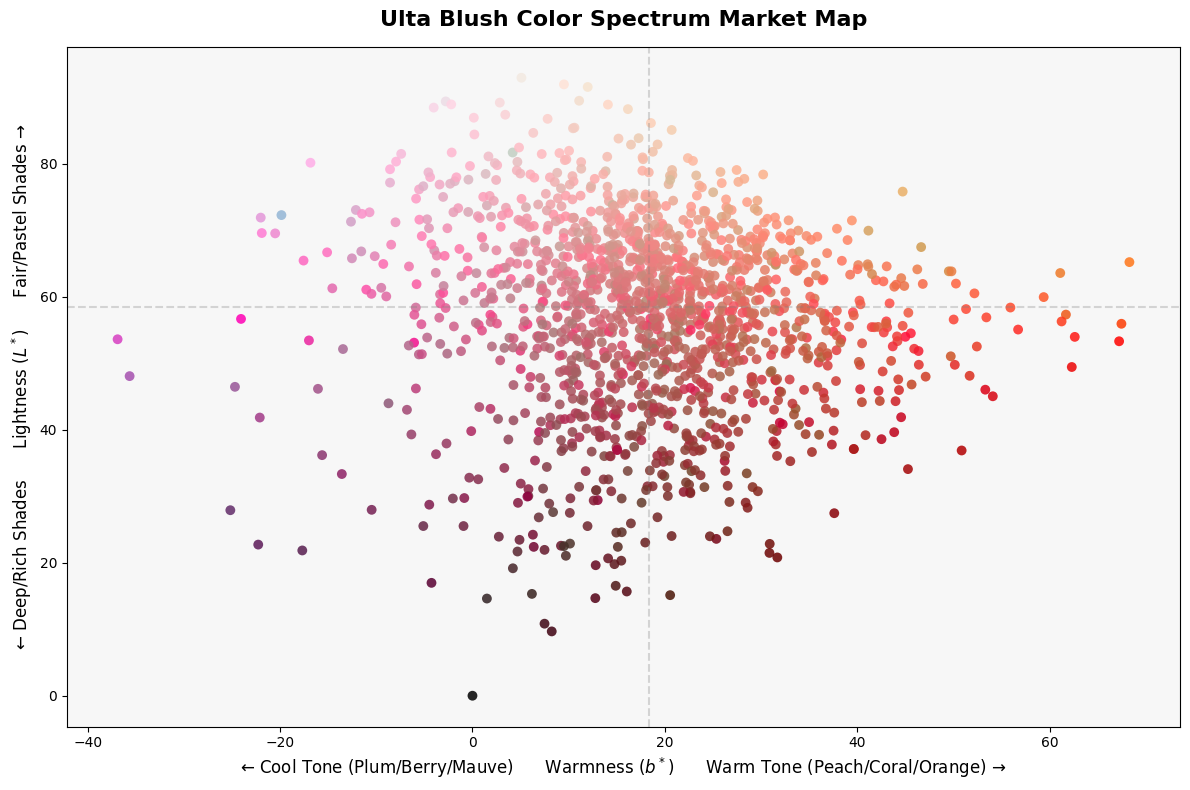

In [9]:
# 4. Create the plot
plt.figure(figsize=(12, 8))
plt.rcParams['axes.facecolor'] = '#F7F7F7' # Soft gray background so light/dark blushes are both visible

# Scatter plot using the actual color of each blush for its marker
scatter = plt.scatter(
    x=plot_df['b_axis'], 
    y=plot_df['L_axis'], 
    c=plot_df['hex_color'], 
    s=50,               # Size of dots
    alpha=0.85,         # Slight transparency helps see density over overlaps
    edgecolors='none'   # No border outlines for a cleaner spectrum cloud
)

# Labeling and Formatting
plt.title('Ulta Blush Color Spectrum Market Map', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('← Cool Tone (Plum/Berry/Mauve)      Warmness ($b^*$)      Warm Tone (Peach/Coral/Orange) →', fontsize=12)
plt.ylabel('← Deep/Rich Shades      Lightness ($L^*$)      Fair/Pastel Shades →', fontsize=12)

# Add faint center lines to establish quadrants
plt.axvline(x=plot_df['b_axis'].median(), color='gray', linestyle='--', alpha=0.3, label='Median Warmth')
plt.axhline(y=plot_df['L_axis'].median(), color='gray', linestyle='--', alpha=0.3, label='Median Lightness')

plt.tight_layout()
plt.show()

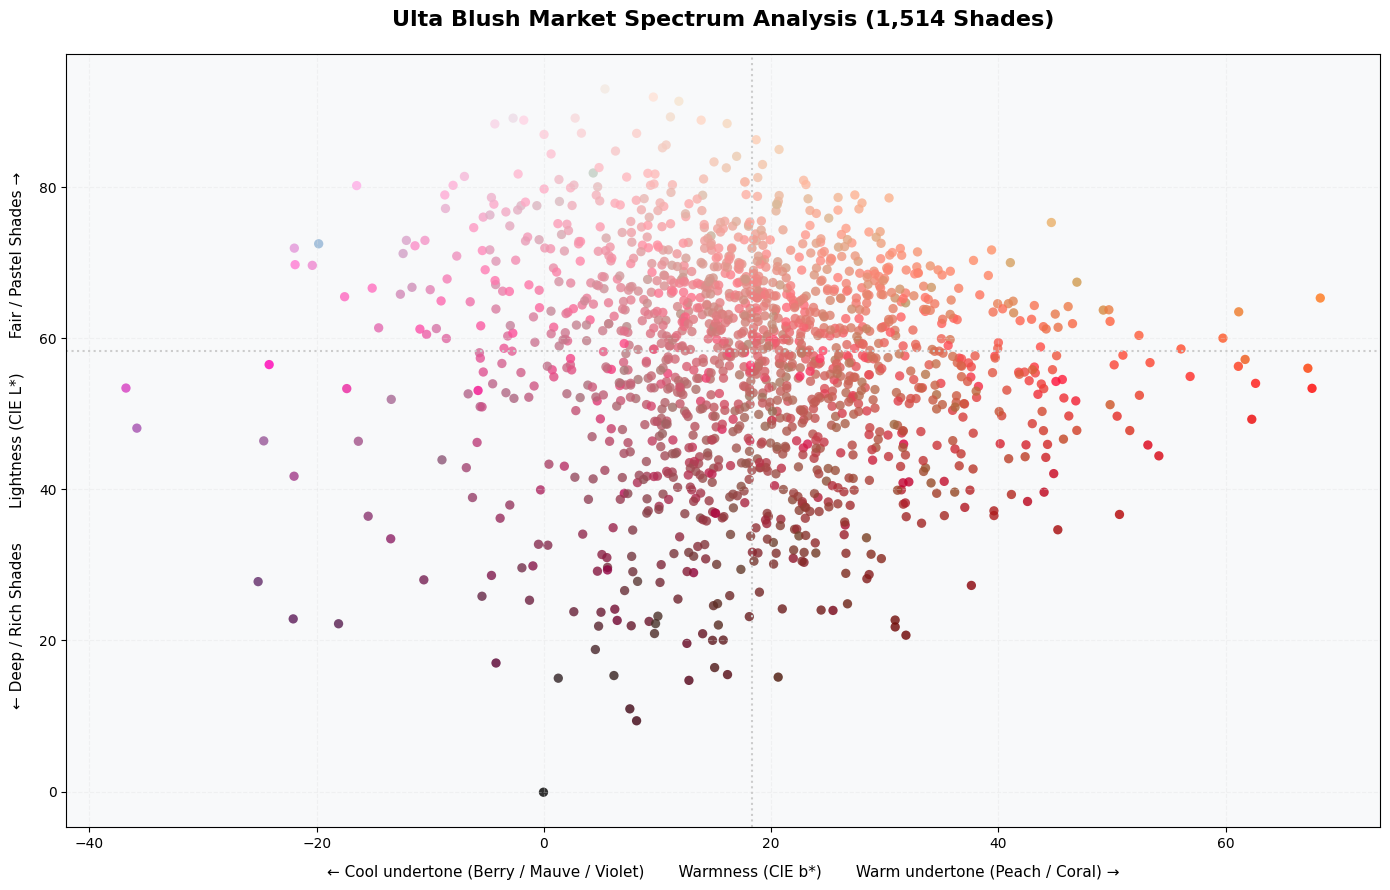

In [12]:
# 2. Clean up data: ensure we have numeric values and drop missing values
plot_df = df.dropna(subset=['lab_L', 'lab_b', 'rgb_r', 'rgb_g', 'rgb_b']).copy()

# 3. Vectorized conversion of RGB columns to Hex strings for matplotlib
def row_to_hex(row):
    return '#%02x%02x%02x' % (int(row['rgb_r']), int(row['rgb_g']), int(row['rgb_b']))

plot_df['hex_color'] = plot_df.apply(row_to_hex, axis=1)

# 4. Apply a tiny amount of visual jitter so overlapping points are visible
np.random.seed(42) # For consistent plotting
jitter_x = np.random.normal(0, 0.2, size=len(plot_df))
jitter_y = np.random.normal(0, 0.2, size=len(plot_df))

# 5. Build the Spectrum Visualization
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#F8F9FA')  # Light off-white background

# Map b onto X-axis, and L onto Y-axis
scatter = ax.scatter(
    x=plot_df['lab_b'] + jitter_x,
    y=plot_df['lab_L'] + jitter_y,
    c=plot_df['hex_color'],
    s=45,
    alpha=0.8,
    edgecolors='none'  # Clean edges makes it look like a smooth gradient cloud
)

# 6. Styling and Strategic Context Lines
ax.set_title('Ulta Blush Market Spectrum Analysis (1,514 Shades)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('← Cool undertone (Berry / Mauve / Violet)       Warmness (CIE b*)       Warm undertone (Peach / Coral) →', fontsize=11, labelpad=10)
ax.set_ylabel('← Deep / Rich Shades       Lightness (CIE L*)       Fair / Pastel Shades →', fontsize=11, labelpad=10)

# Add quadrant lines using medians to easily spot empty market quadrants
median_b = plot_df['lab_b'].median()
median_L = plot_df['lab_L'].median()

ax.axvline(x=median_b, color='#CCCCCC', linestyle=':', linewidth=1.5, label=f'Median Warmth ({median_b:.1f})')
ax.axhline(y=median_L, color='#CCCCCC', linestyle=':', linewidth=1.5, label=f'Median Lightness ({median_L:.1f})')

# Clean up layout adjustments
ax.grid(True, linestyle='--', alpha=0.3, color='#DDDDDD')
plt.tight_layout()


# plt.savefig('blush_market_gap_analysis.png', dpi=300) # Save plot to disk
plt.show()

**1. The Saturation Zone**

With 1514 colors, there is an incredibly dense, crowded cluster right in the middle-to-upper right section. This zone is heavily saturated with mid-tone coral, warm peach, pinky-beige, and terracotta blushes. Brands lean heavily into this quadrant because these warm, medium-light shades are historically considered "safe" commerical successes that appeal broadly to fair-to-medium skin tones with warm undertone.

**2. The K-Beauty Pastel Wave**

Notice the dense, high-lightness ceiling stretching across the top, where $L*$ climbs past 75 and even approaches 90. These are very fair, pale, pastel-pink, lilac, and soft peach blushes. This region reflects the massive commercial rise of brightening, translucent blush formulations popular in East Asian (K-Beauty/C-Beauty) makeup trends, which are designed to pop on very fair complexions. 

**3. The True Market Gap**

Looking closely at where the dots thin out reveals clear white spaces. If you were launching a beauty brand or expanding a product line, these are the regions to target:
- **The Deep & Cool Desert (Bottom Left)**: Look at the quadrant where Lightness ($L^*$) drops below 40 and Warmness ($b^*$) drops below 10. The dots here become remarkably sparse. True, rich, deep-toned cool blushes—such as intense plums, deep eggplants, and vivid dark berries tailored for deep skin tones—are significantly underrepresented compared to the lighter quadrants.
- **The "Neon" Cool Extremes (Far Left Edge)**: Notice those few striking pink dots out past $b^* = -30$. There are very few data points on that far-left edge. Highly vibrant, cool-toned magenta and pure bubblegum neon pinks are relatively rare, isolated formulations rather than industry standards.
- **The Extreme Dark Hole (Bottom Center)**: There is one solitary black dot sitting at $L^* = 0, b^* = 0$. This represents a pure black or color-changing pH blush (which looks black in the pan but goes on clear/pink). The extreme bottom edge ($L^*$ below 20) is almost entirely empty, proving that the market rarely formulates ultra-deep pigment bases for blush.

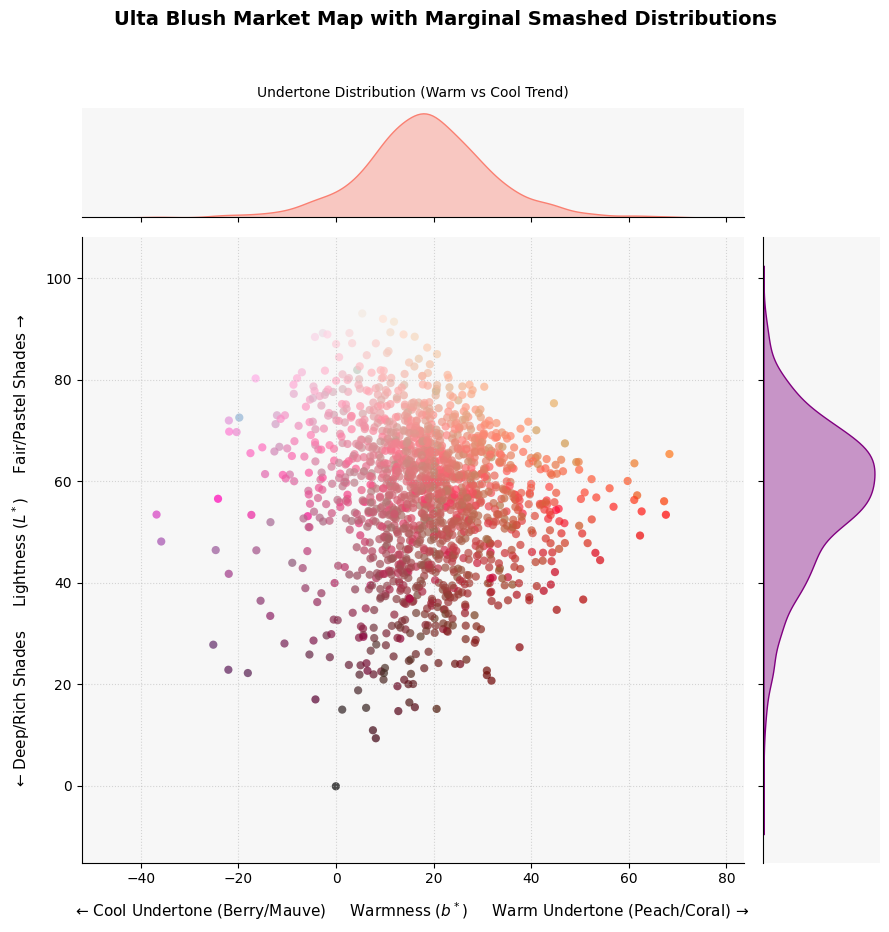

In [19]:
# 2. Convert RGB columns into a hex string for plotting
plot_df['hex_color'] = plot_df.apply(lambda r: '#%02x%02x%02x' % (int(r['rgb_r']), int(r['rgb_g']), int(r['rgb_b'])), axis=1)

# 3. Apply a tiny bit of random jitter so overlaps don't hide data density
np.random.seed(42)
plot_df['jitter_b'] = plot_df['lab_b'] + np.random.normal(0, 0.2, size=len(plot_df))
plot_df['jitter_L'] = plot_df['lab_L'] + np.random.normal(0, 0.2, size=len(plot_df))

# 4. Initialize the JointGrid
g = sns.JointGrid(data=plot_df, x='jitter_b', y='jitter_L', height=9)

# 5. Populate the central scatter map using the individual swatch colors
g.plot_joint(
    plt.scatter, 
    c=plot_df['hex_color'], 
    s=35, 
    alpha=0.7, 
    edgecolors='none'
)

# 6. Populate the "Smashed" marginal distributions safely using Seaborn's built-in hooks
# Top marginal (X-axis) gets the warmth/coolness curve
sns.kdeplot(data=plot_df, x='lab_b', ax=g.ax_marg_x, color='salmon', fill=True, alpha=0.4)
# Right marginal (Y-axis) gets the depth/value curve
sns.kdeplot(data=plot_df, y='lab_L', ax=g.ax_marg_y, color='purple', fill=True, alpha=0.4)

# 7. Labels and Clean Styling
g.ax_joint.set_xlabel('← Cool Undertone (Berry/Mauve)     Warmness ($b^*$)     Warm Undertone (Peach/Coral) →', fontsize=11, labelpad=10)
g.ax_joint.set_ylabel('← Deep/Rich Shades     Lightness ($L^*$)     Fair/Pastel Shades →', fontsize=11, labelpad=10)
g.ax_joint.grid(True, linestyle=':', alpha=0.5)

# Add titles to the sub-axes for maximum clarity
g.ax_marg_x.set_title("Undertone Distribution (Warm vs Cool Trend)", fontsize=10, pad=8)

plt.suptitle('Ulta Blush Market Map with Marginal Smashed Distributions', y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout()

# Save and render
# plt.savefig('smashed_distributions_fixed.png', dpi=300, bbox_inches='tight')
plt.show()